In [24]:
import pandas as pd 
import numpy as np

In [ ]:
df=pd.read_csv("../Dataset/Cleaned_data.csv")
data=df.copy()
data

## Building new features to check if participants failed any lift

In [ ]:
lift_categories=['Squat1','Squat2','Squat3','Benchpress1','Benchpress2','Benchpress3','Deadlift1','Deadlift2','Deadlift3']
for i in lift_categories:
    data[f'Failed_{i}']=np.where(data[i]<0,'Y','N')
    data[f'Actual_{i}']=data[i]
    data[i]=np.where(data[i]<0,abs(data[i]),data[i])
data

## Building new feature - Age of Participants (Year of Competitions-2024)

In [27]:
data['Age']=2024-data['YOB']
print(f"Average age:{data['Age'].mean():.0f} \nMaximum age:{data['Age'].max()} \nMinimum age:{data['Age'].min()}")

Average age:30 
Maximum age:85 
Minimum age:14


## Checking for Outliers and Removal of Outliers

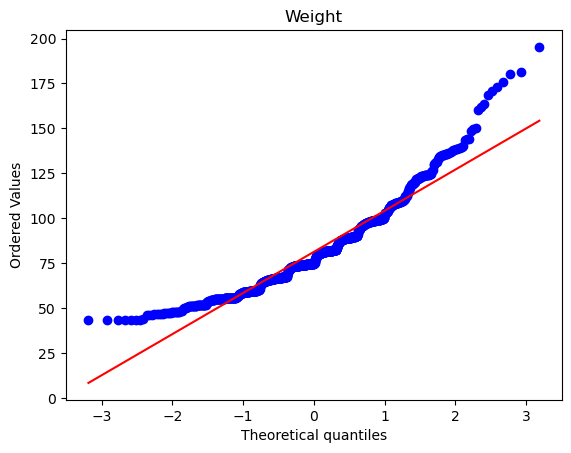

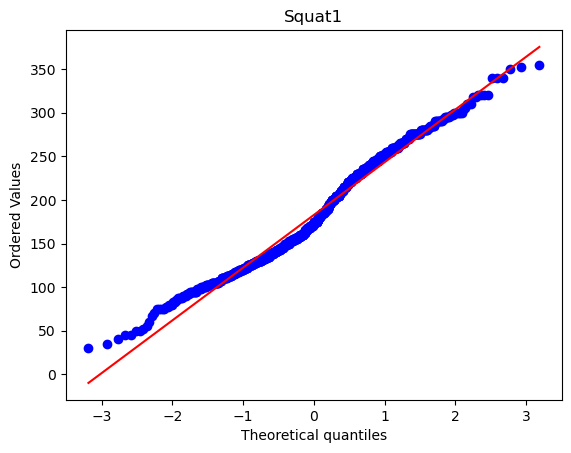

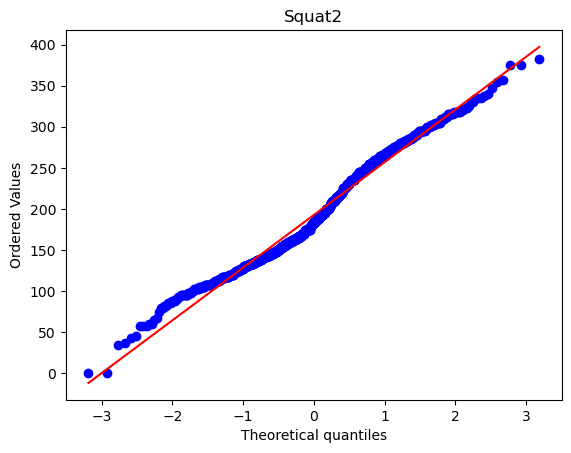

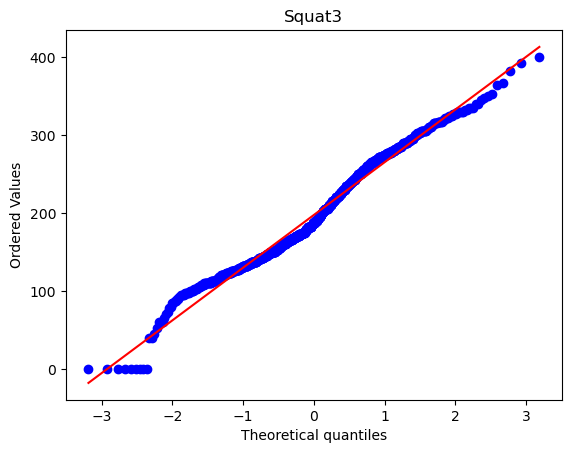

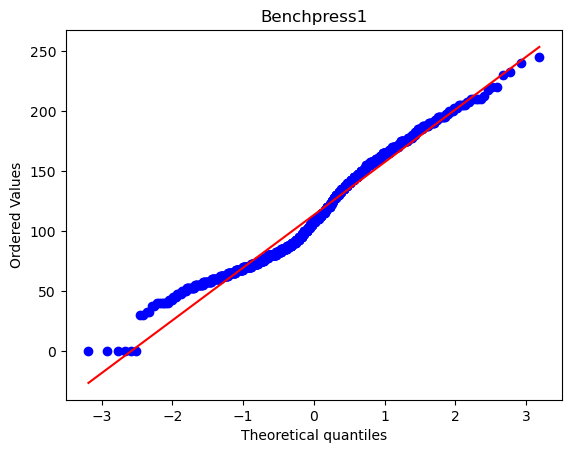

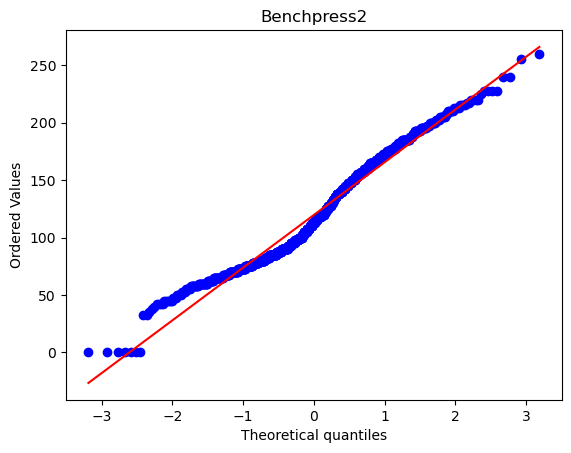

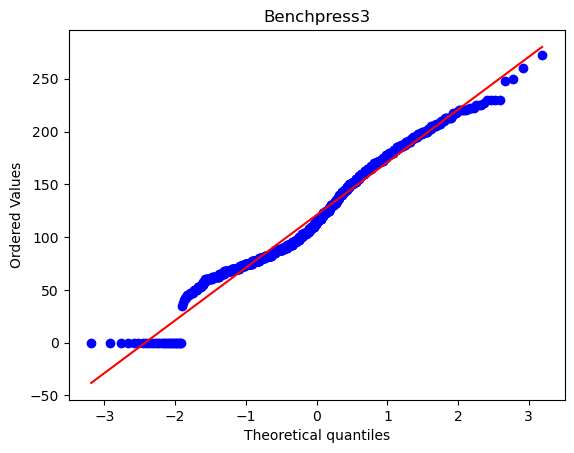

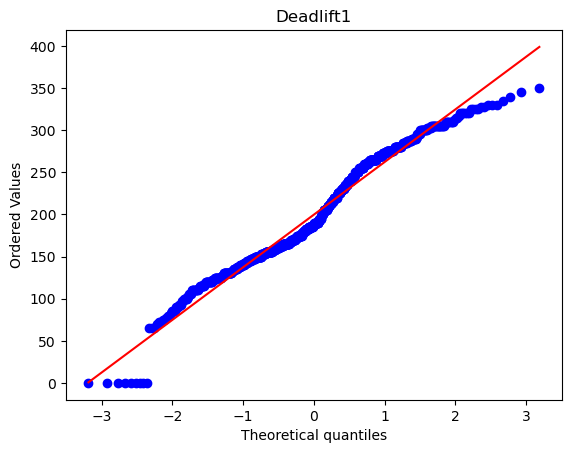

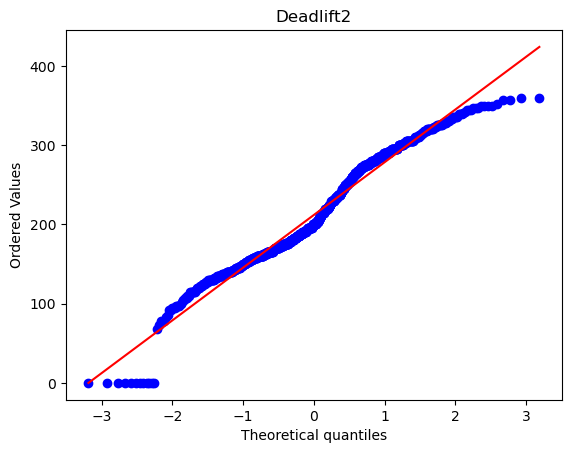

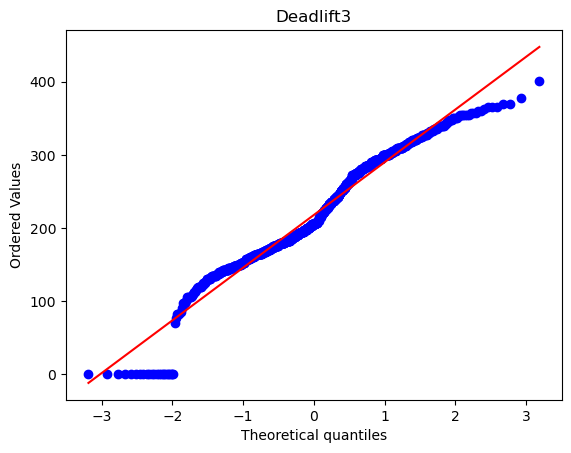

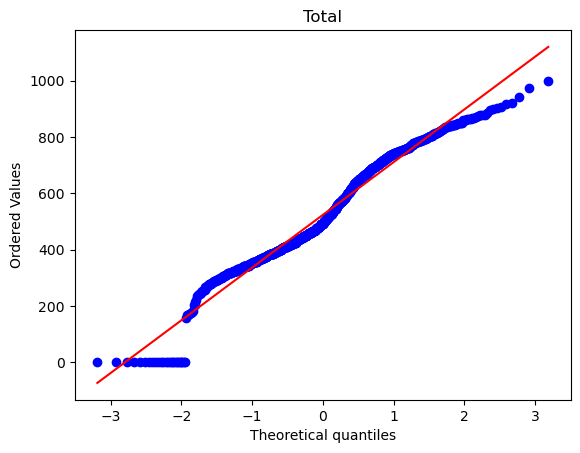

In [31]:
# USING Quantile-Quantile plot to check if the data is normally distributed and to check for outliers
# Features other than Weight are quite normally distributed and Weight is right skewed

import scipy.stats as stats 
import matplotlib.pyplot as plt
outlier_scan=['Weight','Squat1','Squat2','Squat3','Benchpress1','Benchpress2','Benchpress3','Deadlift1','Deadlift2','Deadlift3','Total']
for i in outlier_scan:
    stats.probplot(data[i],dist='norm',plot=plt)
    plt.title(i)
    plt.show()


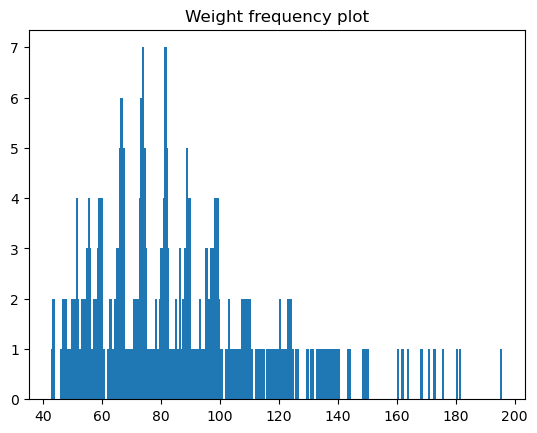

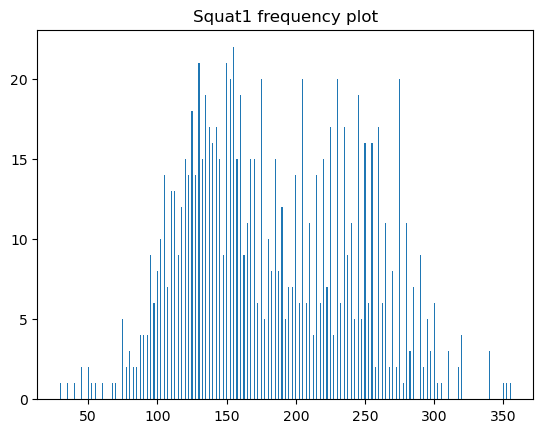

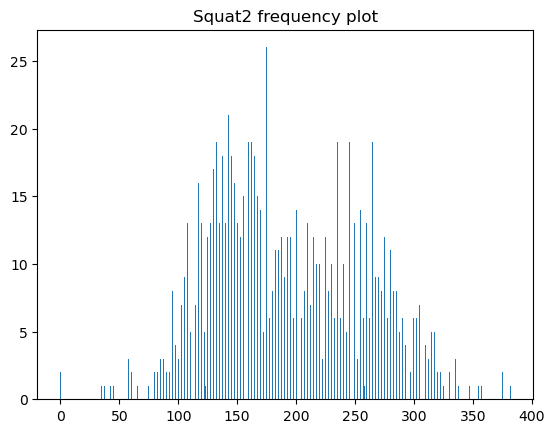

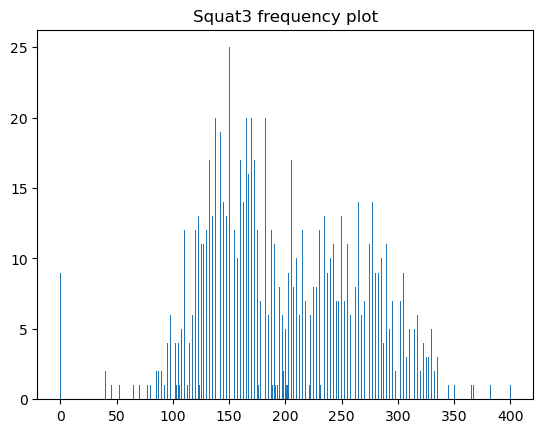

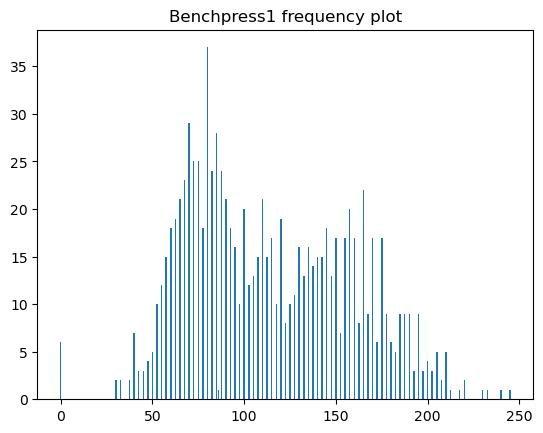

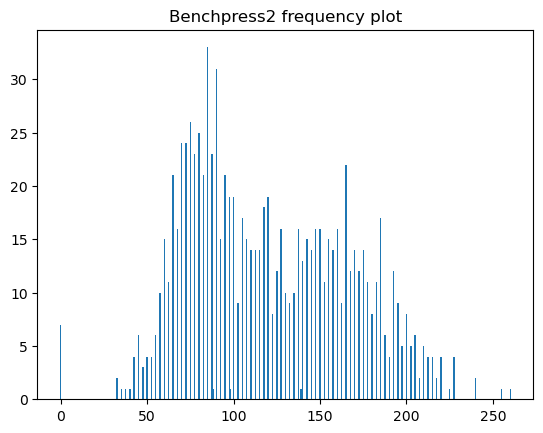

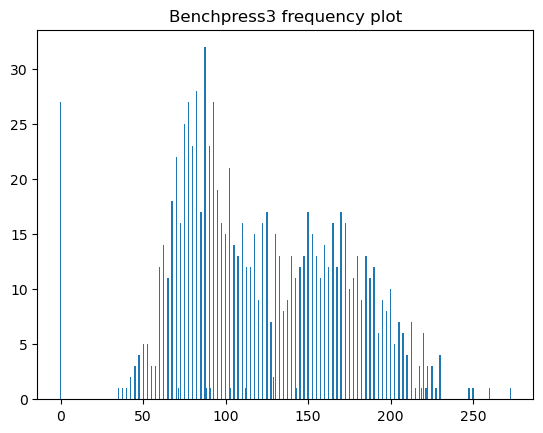

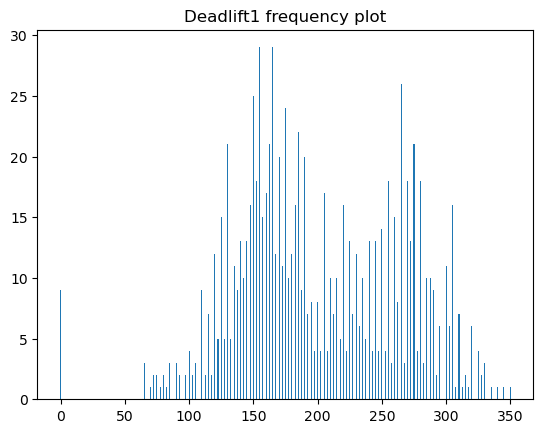

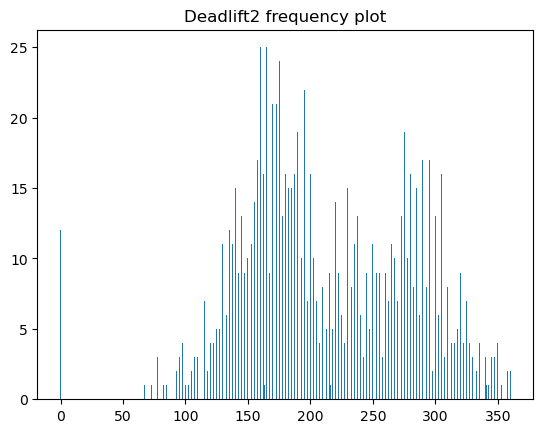

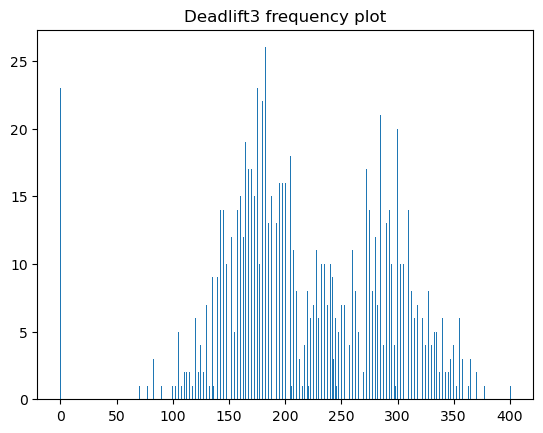

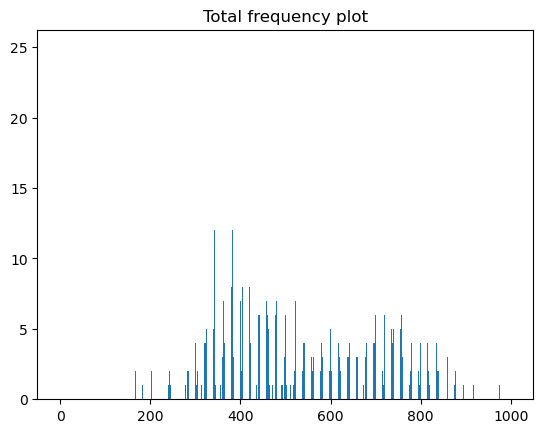

In [14]:
# Using Histogram to check the data is normally distributed and to check for outliers again
# Features other than Weight are quite normally distributed and Weight is right skewed

import matplotlib.pyplot as plt
import numpy as np 
from collections import Counter
outlier_scan=['Weight','Squat1','Squat2','Squat3','Benchpress1','Benchpress2','Benchpress3','Deadlift1','Deadlift2','Deadlift3','Total']
for i in outlier_scan:
    freq=Counter(data[i])
    keys=freq.keys()
    values=freq.values()
    plt.bar(keys,values)
    plt.title(f"{i} frequency plot")
    plt.show()

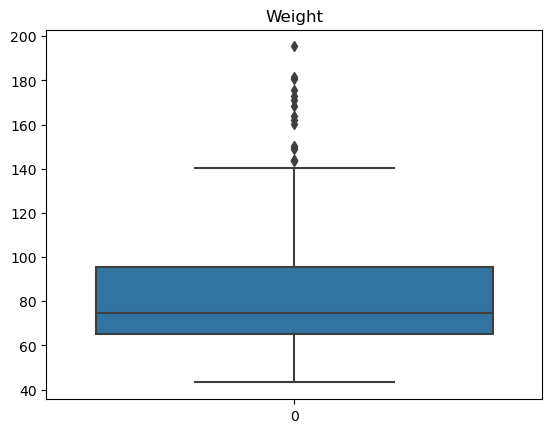

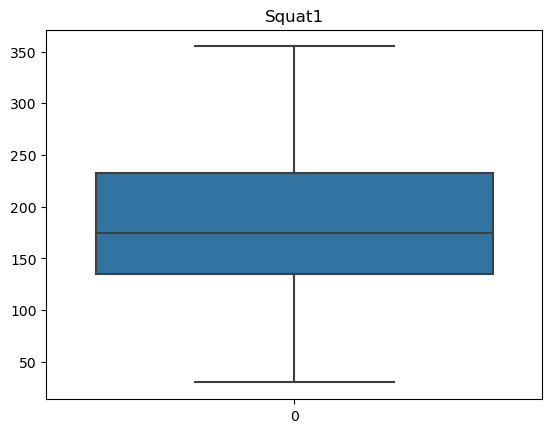

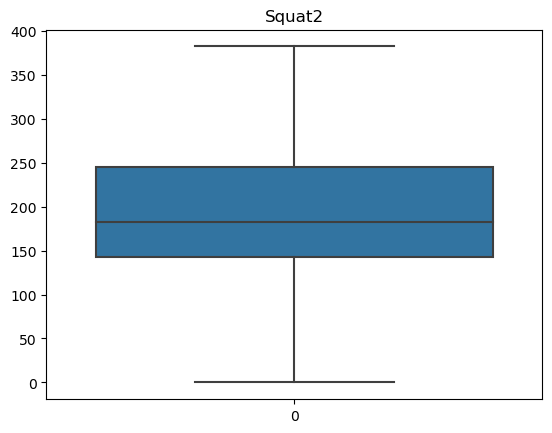

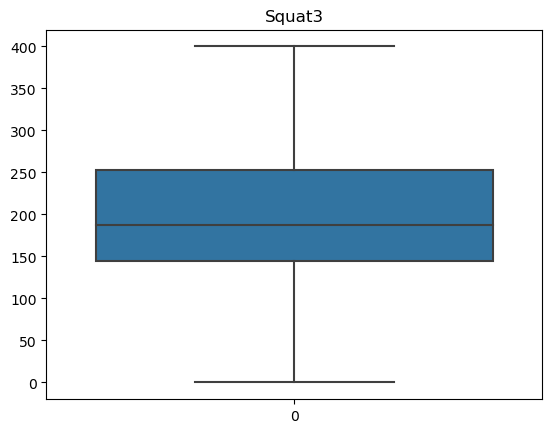

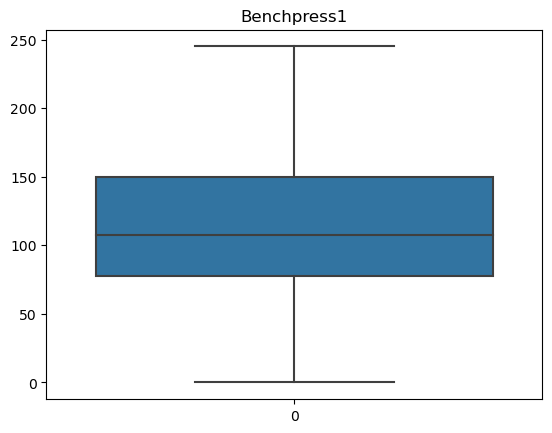

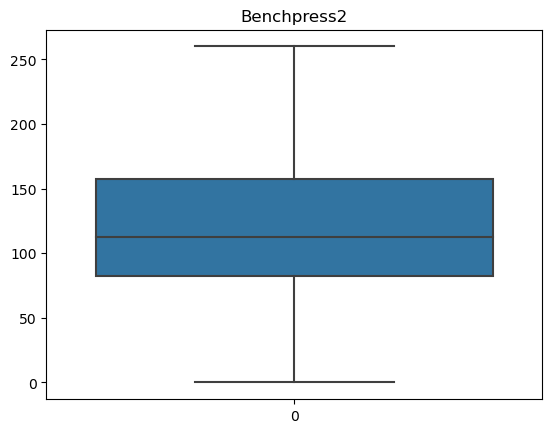

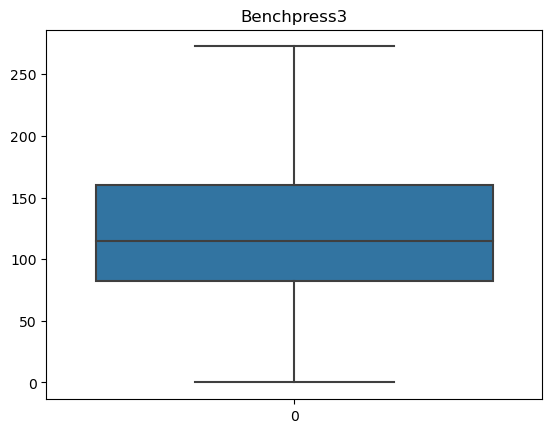

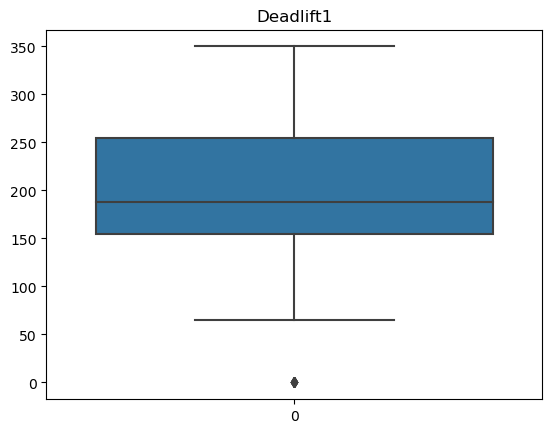

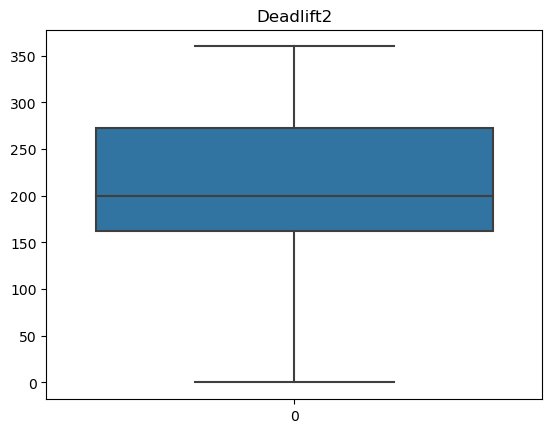

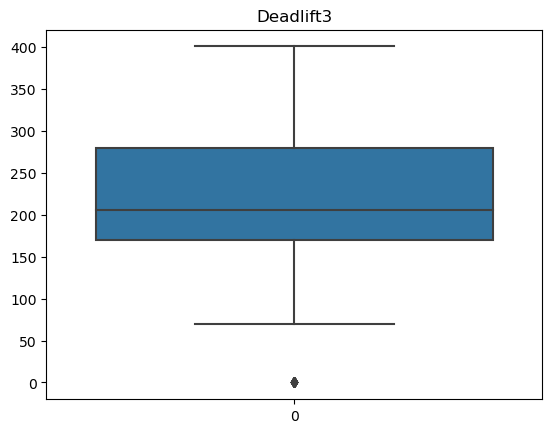

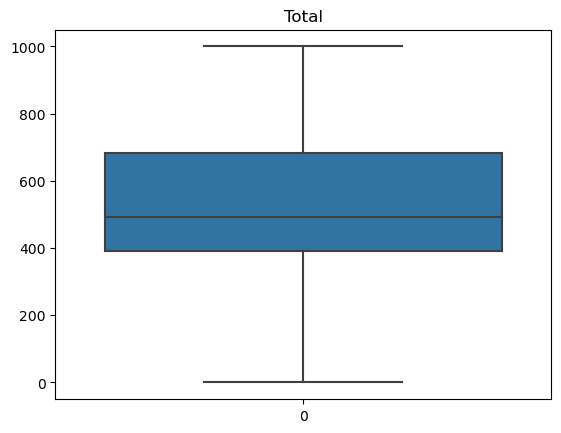

In [15]:
# USING BOXPLOT TO CHECK FOR OUTLIERS
import seaborn as sns
import matplotlib.pyplot as plt 
outlier_scan=['Weight','Squat1','Squat2','Squat3','Benchpress1','Benchpress2','Benchpress3','Deadlift1','Deadlift2','Deadlift3','Total']
for i in outlier_scan:
    plt.title(i)
    sns.boxplot(data[i])
    plt.show()

In [16]:
# APPLYING LOG TRANSFORM ON WEIGHT FEATURE AS IT IS RIGHT SKEWED
data['Weight']=np.log(data['Weight'])

In [17]:
# AS ALL THE FEATURES SUCH AS WEIGHT CONTAINS OUTLIERS, WE WILL REMOVE THEM
# SO USING EMPIRICAL RULE TO REMOVE OUTLIERS
outliers_present=['Weight','Deadlift1','Deadlift3']
for i in outliers_present:  
    min_limit=data[i].mean()-3*data[i].std()    # as the data is fairly normal distributed 
    max_limit=data[i].mean()+3*data[i].std()    # as the data is fairly normal distributed 
    data=data[(data[i]<max_limit) & (data[i]>min_limit)]

## Applying Chi-Square Test on Categorical target features vs Categorical Independent features

In [4]:
from scipy.stats import chi2_contingency, f_oneway

def chi_square_test(df, categorical_target, categorical_feature):
    contingency_table = pd.crosstab(df[categorical_target], df[categorical_feature])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    return p

In [9]:
categorical_features=[i for i in data.columns if data[i].dtype=='object']
# for Failed Squat3
for i in categorical_features:
    print(f"Failed_Squat3 vs {i}:",chi_square_test(data,'Failed_Squat3',i))

Failed_Squat3 vs Name: 0.4515650803214968
Failed_Squat3 vs Gender: 0.38543990478265433
Failed_Squat3 vs State: 0.8759855378717394
Failed_Squat3 vs Failed_Squat1: 0.0076007548958033355
Failed_Squat3 vs Failed_Squat2: 0.005768219116041495
Failed_Squat3 vs Failed_Squat3: 6.365406849708951e-211
Failed_Squat3 vs Failed_Benchpress1: 0.10950554391480975
Failed_Squat3 vs Failed_Benchpress2: 0.010558314524494735
Failed_Squat3 vs Failed_Benchpress3: 0.16647509831562096
Failed_Squat3 vs Failed_Deadlift1: 0.03702661789319
Failed_Squat3 vs Failed_Deadlift2: 0.07814493960816368
Failed_Squat3 vs Failed_Deadlift3: 0.01470470091078591


In [10]:
# for Failed Deadlift3
for i in categorical_features:
    print(f"Failed_Deadlift3 vs {i}:",chi_square_test(data,'Failed_Deadlift3',i))

Failed_Deadlift3 vs Name: 0.48758249089091893
Failed_Deadlift3 vs Gender: 0.001226569025915172
Failed_Deadlift3 vs State: 0.5818647490742397
Failed_Deadlift3 vs Failed_Squat1: 0.22332619172594306
Failed_Deadlift3 vs Failed_Squat2: 0.23945744577365993
Failed_Deadlift3 vs Failed_Squat3: 0.01470470091078591
Failed_Deadlift3 vs Failed_Benchpress1: 0.01451210117858689
Failed_Deadlift3 vs Failed_Benchpress2: 0.7924131631814871
Failed_Deadlift3 vs Failed_Benchpress3: 0.28077330157129643
Failed_Deadlift3 vs Failed_Deadlift1: 0.32365969059955435
Failed_Deadlift3 vs Failed_Deadlift2: 0.07460745816345005
Failed_Deadlift3 vs Failed_Deadlift3: 5.805416229610425e-211


In [11]:
# for Failed Benchpress3
for i in categorical_features:
    print(f"Failed_Benchpress3 vs {i}:",chi_square_test(data,'Failed_Benchpress3',i))

Failed_Benchpress3 vs Name: 0.5063725960316725
Failed_Benchpress3 vs Gender: 0.21643948974098995
Failed_Benchpress3 vs State: 0.444338205510236
Failed_Benchpress3 vs Failed_Squat1: 0.24191971927380096
Failed_Benchpress3 vs Failed_Squat2: 0.07650486523273148
Failed_Benchpress3 vs Failed_Squat3: 0.16647509831562096
Failed_Benchpress3 vs Failed_Benchpress1: 1.0
Failed_Benchpress3 vs Failed_Benchpress2: 0.00023470232258078147
Failed_Benchpress3 vs Failed_Benchpress3: 5.785830108267709e-211
Failed_Benchpress3 vs Failed_Deadlift1: 0.8589264009002902
Failed_Benchpress3 vs Failed_Deadlift2: 0.412100545158538
Failed_Benchpress3 vs Failed_Deadlift3: 0.28077330157129643


## Encoding of Categorical data

In [19]:
from sklearn.preprocessing import LabelEncoder
import pickle
encoder_for_status=LabelEncoder()
cat_features_Status=['Failed_Squat1','Failed_Squat2', 'Failed_Squat3', 'Failed_Benchpress1','Failed_Benchpress2', 'Failed_Benchpress3', 'Failed_Deadlift1','Failed_Deadlift2', 'Failed_Deadlift3']
for i in cat_features_Status:
    data[i]=encoder_for_status.fit_transform(data[i])
pickle.dump(encoder_for_status,open('../Models/Status_encoder.sav','wb'))
encoder_for_gender=LabelEncoder()
data['Gender']=encoder_for_gender.fit_transform(data['Gender'])
pickle.dump(encoder_for_gender,open('../Models/Gender_encoder.sav','wb'))

In [20]:
data=data.drop(columns=["YOB","Lot","State","Points","Name"])

In [22]:
data.to_csv("../Dataset/After_preprocessing.csv",index=False)